✅ Trend data collected: (261, 5)


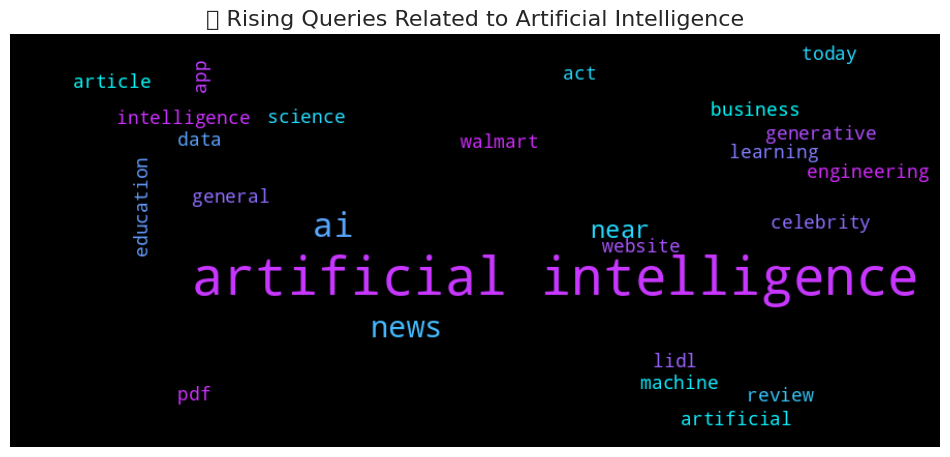

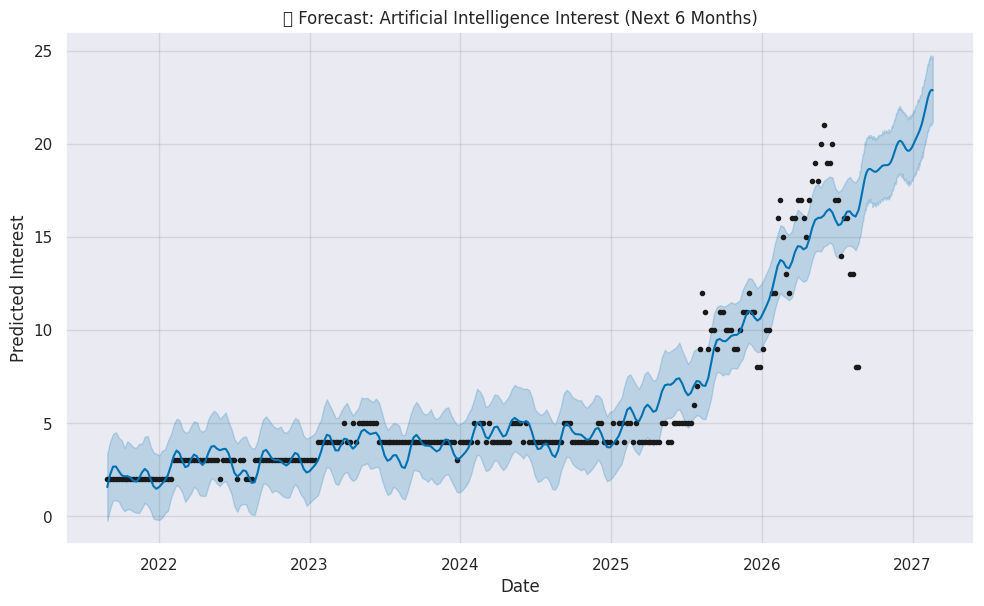


📊 TREND SCORECARD
                Keyword  Avg Interest (5y)  Current Interest  Growth %
          Cybersecurity               5.24                 9     800.0
Artificial Intelligence               5.74                 8     300.0
      Quantum Computing               1.49                 3     300.0
                     5G              66.33                92     135.9
             Blockchain               5.15                 4     -20.0



✅ All files exported: CSV ready for report/presentation


In [1]:
# =====================================================================
# 🚀 TECHNOLOGY TREND ANALYTICS PLATFORM — Full Project
# =====================================================================

# ---------- 1. Install dependencies ----------
!pip install pytrends pandas matplotlib seaborn plotly prophet requests wordcloud --quiet

# ---------- 2. Imports ----------
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
from wordcloud import WordCloud
import requests
import warnings
warnings.filterwarnings("ignore")

sns.set(style="darkgrid")

# =====================================================================
# MODULE 1: GOOGLE TRENDS DATA COLLECTION
# =====================================================================
pytrends = TrendReq(hl='en-US', tz=330)

tech_keywords = ["Artificial Intelligence", "Blockchain", "Quantum Computing", "5G", "Cybersecurity"]

pytrends.build_payload(tech_keywords, cat=0, timeframe='today 5-y', geo='', gprop='')
trend_data = pytrends.interest_over_time()
if 'isPartial' in trend_data.columns:
    trend_data = trend_data.drop(columns=['isPartial'])

print("✅ Trend data collected:", trend_data.shape)
trend_data.tail()

# =====================================================================
# MODULE 2: INTERACTIVE VISUALIZATION (Plotly Dashboard-style)
# =====================================================================
fig = go.Figure()
for kw in tech_keywords:
    fig.add_trace(go.Scatter(x=trend_data.index, y=trend_data[kw],
                              mode='lines', name=kw))
fig.update_layout(title="📈 Technology Trend Popularity (5 Years)",
                   xaxis_title="Date", yaxis_title="Search Interest (0-100)",
                   template="plotly_dark", height=500)
fig.show()

# =====================================================================
# MODULE 3: REGIONAL ANALYSIS
# =====================================================================
region_data = pytrends.interest_by_region(resolution='COUNTRY', inc_low_vol=True)
top_countries = region_data.sort_values(by=tech_keywords[0], ascending=False).head(15)

fig2 = px.bar(top_countries, x=top_countries.index, y=tech_keywords[0],
              title=f"🌍 Top Countries Interested in {tech_keywords[0]}",
              color=tech_keywords[0], color_continuous_scale="Viridis")
fig2.show()

# =====================================================================
# MODULE 4: RISING & RELATED QUERIES (WordCloud)
# =====================================================================
related = pytrends.related_queries()
rising_queries = related[tech_keywords[0]]['rising']

if rising_queries is not None:
    text = " ".join(rising_queries['query'].astype(str))
    wc = WordCloud(width=900, height=400, background_color="black",
                    colormap="cool").generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"🔥 Rising Queries Related to {tech_keywords[0]}", fontsize=16)
    plt.show()

# =====================================================================
# MODULE 5: TREND FORECASTING (Prophet — predict next 6 months)
# =====================================================================
forecast_kw = tech_keywords[0]
df_prophet = trend_data.reset_index()[['date', forecast_kw]]
df_prophet.columns = ['ds', 'y']

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)

fig3 = model.plot(forecast)
plt.title(f"🔮 Forecast: {forecast_kw} Interest (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Predicted Interest")
plt.show()

# =====================================================================
# MODULE 6: TREND COMPARISON SCORECARD
# =====================================================================
summary = pd.DataFrame({
    "Keyword": tech_keywords,
    "Avg Interest (5y)": [trend_data[k].mean().round(2) for k in tech_keywords],
    "Current Interest": [trend_data[k].iloc[-1] for k in tech_keywords],
    "Growth %": [
        round(((trend_data[k].iloc[-1] - trend_data[k].iloc[0]) /
               max(trend_data[k].iloc[0], 1)) * 100, 2)
        for k in tech_keywords
    ]
}).sort_values(by="Growth %", ascending=False)

print("\n📊 TREND SCORECARD")
print(summary.to_string(index=False))

fig4 = px.bar(summary, x="Keyword", y="Growth %", color="Growth %",
              title="📈 5-Year Growth % by Technology", color_continuous_scale="RdYlGn")
fig4.show()

# =====================================================================
# MODULE 7: EXPORT RESULTS
# =====================================================================
trend_data.to_csv("tech_trends_over_time.csv")
region_data.to_csv("tech_trends_by_region.csv")
summary.to_csv("tech_trend_scorecard.csv", index=False)
forecast.to_csv("tech_trend_forecast.csv", index=False)

print("\n✅ All files exported: CSV ready for report/presentation")